In [1]:
import pandas as pd 
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import shap
import joblib

In [2]:
df = pd.read_excel(r"D:\ML & AI\_Projects\Mining & Heavy Equipment\Mining-and-Heavy-Equipment\Heavy Machinenary DataBase.xlsx")

In [3]:
df.head()

,date,Ton-kilometer fuel consumption L / km / t,vehicle model,Mileage km,Actual fueling quantity L,Average temperature ( ° F ),Average wind speed ( knots ),Maximum temperature ( ° F ),Minimum temperature ( ° F ),Precipitation ( in ),...,shift work,Raise height difference,Width of working flat,Engine power (HP),Engine size (L),Vehicle weight (kg),Transmission type,Fuel Type,Numbers of cylinder,Load Capacity
0,2023-04-20,0.021914,RTH136,NaN,NaN,41.8,3.6,54.7,25.5,0.0,...,night shift,95,30,764,15.93,48000,Automatic,Diesel,6,100000
1,2023-04-21,0.028246,RTH136,NaN,NaN,48.3,3.3,59.9,28.8,0.0,...,day shift,95,30,764,15.93,48000,Automatic,Diesel,6,100000
2,2023-04-21,0.022779,RTH136,NaN,NaN,48.3,3.3,59.9,28.8,0.0,...,night shift,95,30,764,15.93,48000,Automatic,Diesel,6,100000
3,2023-04-22,0.027787,RTH136,NaN,NaN,52.1,5.8,62.4,33.6,0.0,...,day shift,95,30,764,15.93,48000,Automatic,Diesel,6,100000
4,2023-04-22,0.024141,RTH136,NaN,NaN,52.1,5.8,62.4,33.6,0.0,...,night shift,95,30,764,15.93,48000,Automatic,Diesel,6,100000


In [4]:
X = df.drop(columns = ['Ton-kilometer fuel consumption L / km / t'])
y = df['Ton-kilometer fuel consumption L / km / t']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42)

In [6]:
num_cols = X_train.select_dtypes(include = ['int64', 'float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include = ['object','category','bool']).columns.tolist()

In [7]:
date_col = ['date']
num_cols = [col for col in num_cols if col not in date_col]
cat_cols = [col for col in cat_cols if col not in date_col]

In [8]:
class CyclicDateEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, date_column):
        self.date_column = date_column

    def fit(self, X, y = None):
        return self

    def transform(self, X):
        X = X.copy()
        X[self.date_column] = pd.to_datetime(X[self.date_column])

        dayofyear = X[self.date_column].dt.dayofyear

        X['dayofyear_sin'] = np.sin(2 * np.pi * dayofyear / 365)
        X['dayofyear_cos'] = np.cos(2 * np.pi * dayofyear / 365)

        return X.drop(columns = [self.date_column])

In [9]:
rf_pipeline = Pipeline([
    ('cyclic', CyclicDateEncoder(date_column='date')),
    ('preprocessing', ColumnTransformer([
        ('num', IterativeImputer(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ],remainder = 'drop')),
    ('model', RandomForestRegressor(
        n_estimators=300,
        max_depth=8,
        min_samples_split = 5
    ))
])

In [10]:
rf_pipeline.fit(X_train, y_train)

,steps,"[('cyclic', ...), ('preprocessing', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,date_column,'date'
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


In [15]:
joblib.dump(rf_pipeline, 'rf_pipeline.pk1')

['model_columns.pk1']

In [12]:
y_test_pred = rf_pipeline.predict(X_test)

print("Test_R2", r2_score(y_test, y_test_pred))

Test_R2 0.8733931695120388


In [13]:
pipleine_scores = cross_val_score(rf_pipeline, X_train, y_train, cv=5, scoring='r2')

print("rf_pipeline CV R2 mean:", pipleine_scores.mean())
print("rf_pipeline CV R2 std:", pipleine_scores.std())

rf_pipeline CV R2 mean: 0.8753244887084112
rf_pipeline CV R2 std: 0.06502318210042


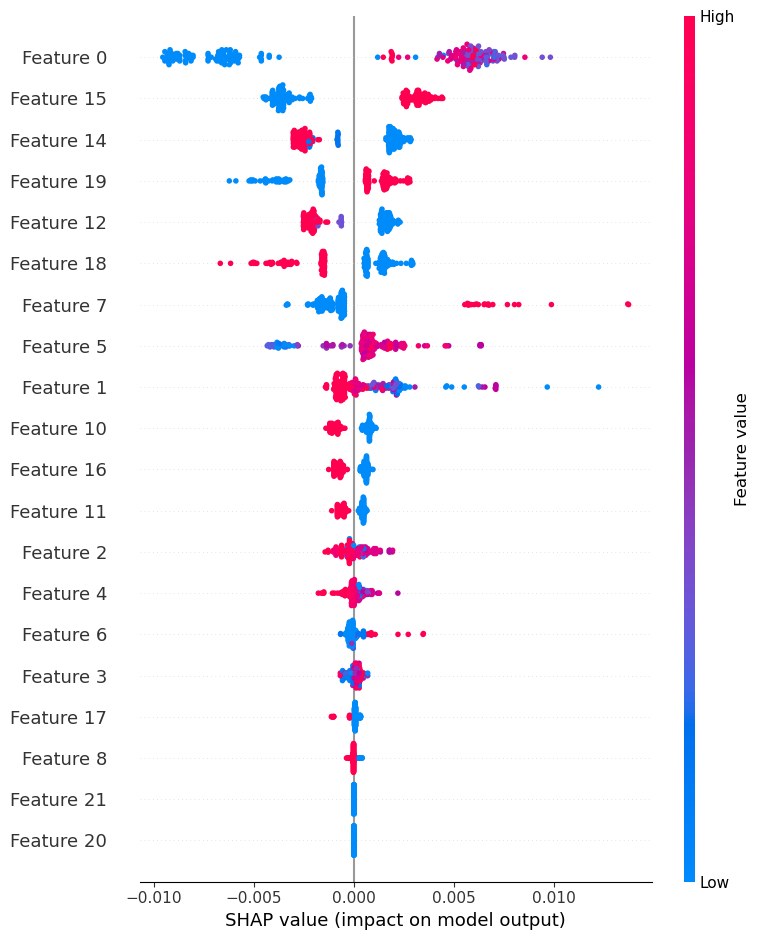

In [14]:
# Extract model
rf_model = rf_pipeline.named_steps['model']

# Transform data
X_transformed = rf_pipeline.named_steps['preprocessing'].transform(X_train)

# SHAP
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_transformed)

# Plot
shap.summary_plot(shap_values, X_transformed)